# Customer Segmentation Analysis

## Objective
The objective of this project is to segment customers of an e-commerce company into distinct groups based on their purchasing behaviour using RFM (Recency, Frequency,Monetary) Analysis and K-Means Clustering. The insights gained can help the business design targerted marketing strategies for different customer segments.

In [1]:
# Import libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

import warnings
warnings.filterwarnings("ignore")

# Display plots inside the notebook
%matplotlib inline

In [2]:
# Load the dataset

df = pd.read_csv("OnlineRetail.csv", encoding="ISO-8859-1")

# Display the first 5 rows of the dataset
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [4]:
# Check the shape of the dataset
print("Dataset Shape:", df.shape)
# Display column names
print("\nColumns:")
print (df.columns)

# Display dataset information
print("\nDataset Information:")
df.info()

Dataset Shape: (541909, 8)

Columns:
Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='str')

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB


## Data Cleaning 

In [5]:
# Check missing values
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


In [8]:
# Remove rows with missing CustomerID
df = df.dropna(subset=['CustomerID'])

# Remove rows with missing Description
df = df.dropna(subset=['Description'])

# Convert InvoiceDate to datetime format
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Convert CustomerID to interger
df['CustomerID'] = df['CustomerID'].astype(int)

# check the cleaned dataset
print(df.info())

<class 'pandas.DataFrame'>
Index: 406829 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    406829 non-null  str           
 1   StockCode    406829 non-null  str           
 2   Description  406829 non-null  str           
 3   Quantity     406829 non-null  int64         
 4   InvoiceDate  406829 non-null  datetime64[us]
 5   UnitPrice    406829 non-null  float64       
 6   CustomerID   406829 non-null  int64         
 7   Country      406829 non-null  str           
dtypes: datetime64[us](1), float64(1), int64(2), str(4)
memory usage: 27.9 MB
None


In [9]:
print("Dataset Shape After Cleaning:")
print(df.shape)

Dataset Shape After Cleaning:
(406829, 8)


## Descriptive Statistics

In [10]:
# Create Total Amount column
df['TotalAmount'] = df['Quantity'] * df['UnitPrice']

# Display the first 5 rows of the dataset after cleaning
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


In [12]:
average_amount = df['TotalAmount'].mean()

print("Average Purchase Value: £{:.2f}".format(average_amount))

Average Purchase Value: £20.40


In [13]:
purchase_frequency = (
    df.groupby("CustomerID")["InvoiceNo"]
    .nunique()
    .reset_index(name="PurchaseFrequency")
)

purchase_frequency.head()

,CustomerID,PurchaseFrequency
0,12346,2
1,12347,7
2,12348,4
3,12349,1
4,12350,1


In [14]:
customer_clv = (
    df.groupby("CustomerID")["TotalAmount"]
    .sum()
    .reset_index(name="CustomerLifetimeValue")
)

customer_clv.head()

,CustomerID,CustomerLifetimeValue
0,12346,0.00
1,12347,4310.00
2,12348,1797.24
3,12349,1757.55
4,12350,334.40


In [17]:
print("Average Purchase Value: £{:.2f}".format(df["TotalAmount"].mean()))

print("Average Purchase Frequency:", purchase_frequency["PurchaseFrequency"].mean())

print("Average Customer Lifetime Value: £{:.2f}".format(customer_clv["CustomerLifetimeValue"].mean()))

Average Purchase Value: £20.40
Average Purchase Frequency: 5.07548032936871
Average Customer Lifetime Value: £1898.46


## Feature Selection (RFM Analysis)

We'll use three customer behaviour features for clustering:

- Recency
- Frequency
- Monetary

In [18]:
# Reference date (one day after the last purchase)

snapshot_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

print(snapshot_date)

2011-12-10 12:50:00


In [20]:
rfm = df.groupby("CustomerID").agg({
    "InvoiceDate": lambda x: (snapshot_date - x.max()).days,
    "InvoiceNo": "nunique",
    "TotalAmount": "sum"
})

rfm.columns = ["Recency", "Frequency", "Monetary"]

rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346,326,2,0.00
12347,2,7,4310.00
12348,75,4,1797.24
12349,19,1,1757.55
12350,310,1,334.40


In [21]:
rfm.describe()

,Recency,Frequency,Monetary
count,4372.000000,4372.000000,4372.000000
mean,92.047118,5.075480,1898.459701
std,100.765435,9.338754,8219.345141
min,1.000000,1.000000,-4287.630000
25%,17.000000,1.000000,293.362500
50%,50.000000,3.000000,648.075000
75%,143.000000,5.000000,1611.725000
max,374.000000,248.000000,279489.020000


## RFM Feature Description

- **Recency:** Numberr of days since the customer's last purchase.
- **Frequency:** Number of unique purchases made by the customer.
- **Monetary:** Total amount spent by the customer.

## Data Normalisation

StandardScarler is used to standardize the RFM features before applying K-means clustering. This ensures that all features contribute equally to the clustering process.

In [24]:
# Select RFM features
rfm_scaled = rfm[["Recency", "Frequency", "Monetary"]]

# Scale the features
scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm_scaled)

In [25]:
# Convert back to DataFrame for viewing
rfm_scaled = pd.DataFrame(
    rfm_scaled,
    columns=["Recency", "Frequency", "Monetary"]
)

rfm_scaled.head()

,Recency,Frequency,Monetary
0,2.322023,-0.329362,-0.231001
1,-0.893733,0.206102,0.293432
2,-0.169196,-0.115176,-0.012316
3,-0.725005,-0.436455,-0.017146
4,2.163220,-0.436455,-0.190312


## K-Means Clustering (Elbow Method)

The Elbow Method helps determine the optimal number of customer clusters by plotting the Within-Cluster Sum of Squares (WCSS) against different values of K.

In [30]:
from sklearn.cluster import KMeans

# calculate WCSS for different values of K
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(rfm_scaled)
    wcss.append(kmeans.inertia_)

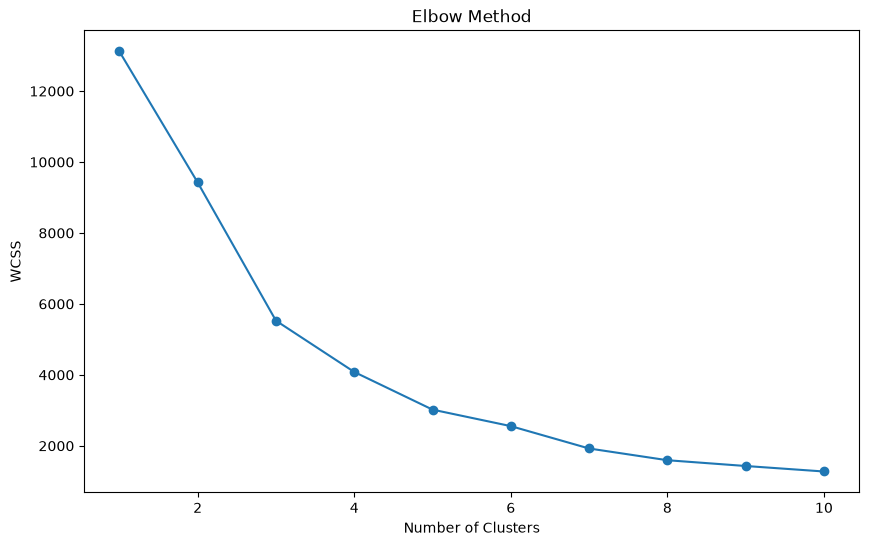

In [31]:
# Plot the Elbow Method
plt.figure(figsize=(10, 6))

plt.plot(range(1, 11), wcss, marker='o')

plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')

plt.show()

## K-Means Clustering

In [33]:
# Apply K-means clustering
kmeans = KMeans(n_clusters=3, random_state=42)

# Fit the model and predict clusters
rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)

# Display first few rows
rfm.head()

,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12346,326,2,0.00,1
12347,2,7,4310.00,0
12348,75,4,1797.24,0
12349,19,1,1757.55,0
12350,310,1,334.40,1


## Cluster Visualization (Recency vs Monetary)

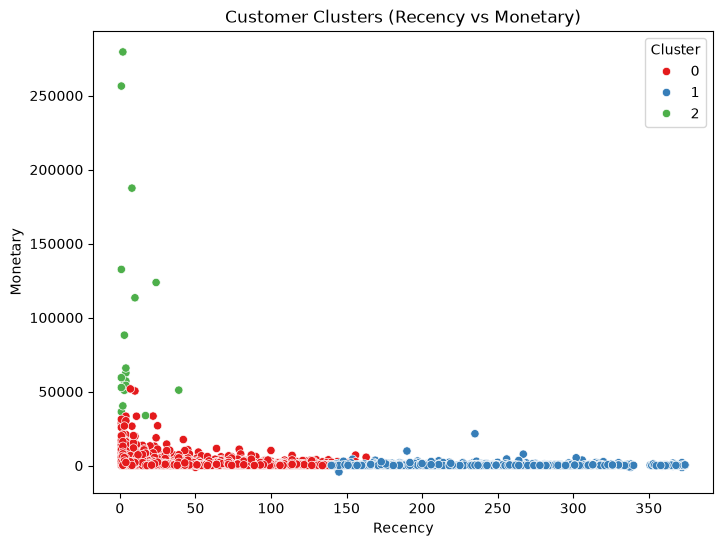

In [34]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=rfm,
    x="Recency",
    y="Monetary",
    hue="Cluster",
    palette="Set1"
)

plt.title("Customer Clusters (Recency vs Monetary)")
plt.show()

## Cluster Visualization (Frequency vs Monetary)

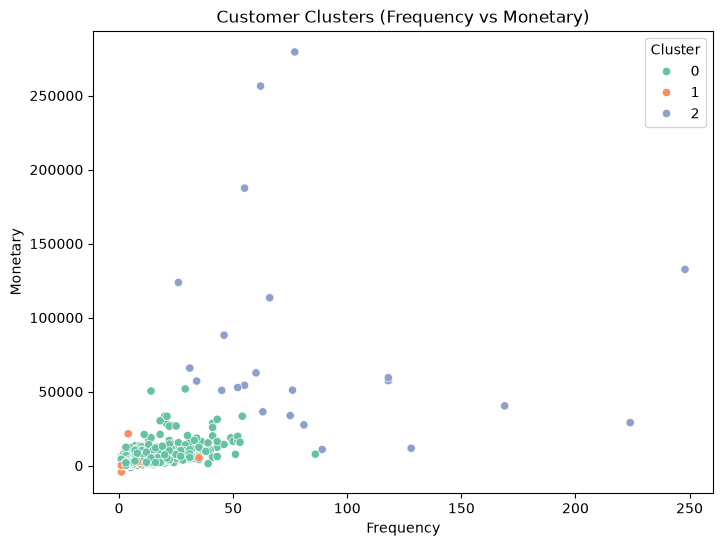

In [35]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=rfm,
    x="Frequency",
    y="Monetary",
    hue="Cluster",
    palette="Set2"
)

plt.title("Customer Clusters (Frequency vs Monetary)")
plt.xlabel("Frequency")
plt.ylabel("Monetary")

plt.show()

## Cluster Profiling

In [37]:
# Calculate average RFM values for each cluster
cluster_profile = rfm.groupby("Cluster")[["Recency", "Frequency", "Monetary"]].mean()

cluster_profile

,Recency,Frequency,Monetary
Cluster,,,
0,40.091245,5.595561,1821.839757
1,246.365611,1.846154,459.541105
2,6.086957,86.869565,81835.857391


## Number of Customers per Cluster

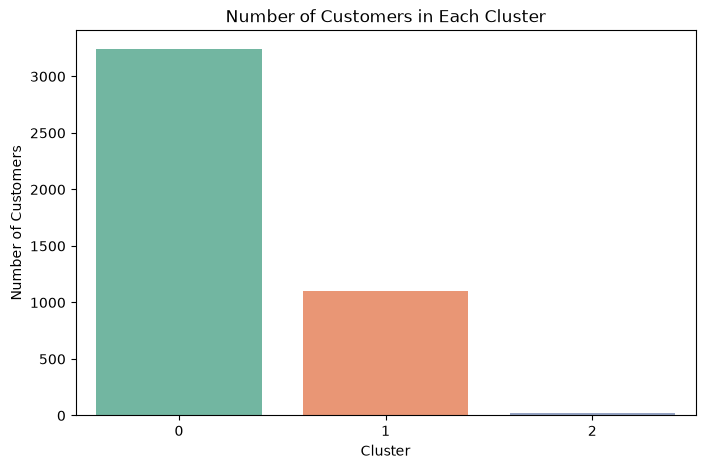

In [38]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=rfm,
    x="Cluster",
    hue="Cluster",
    palette="Set2",
    legend=False
)

plt.title("Number of Customers in Each Cluster")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")

plt.show()

# Insights and Marketing Recommendations

## Cluster 0 - Regular Customers
**Profile:**
- Average Recency: 40.09 days
- Average Frequency: 5.60 purchases
- Average Monetary Value: £1,821.84

**Recommendations:**
- Offer oyalty rewards to encourage repeat purchases.
- Recommend complementary products through personalized suggestions.
- Send occassional discounts and promotional offers to increase purchases frequency.


## Cluster 1 - Inactive Customers
**Profile:**
- Average Recency: 246.37 days
- Average Frequency: 1.85 purchases
- Average Monetary Value: £459.54

**Recommendation**
- Launch re-engagement email campaigns.
- Offer special discounts or coupons to encourage customers to return.
- Send personalised product recommendations based on previous purchases.


## Cluster 2 - VIP / High-Value Customers
**Profile:**
- Average Recency: 6.09 days
- Average Frequency: 86.87 purchases
- Average Monetary Value: £81,835.86

**Recommendation:**
- Provide exclusive VIP membership benefits.
- Offer Early access to new product and premium customer support.
- Reward loyalty wit personalized offers and exclusive promotions.


# Conclusion

The K-Means clustering model successfully segmented customers into three distinct groups based on Recency, Frequency, and Monetary (RFM) values. These customer segments can help the company implement targeted marketing strategies, improve customer retention, increase sales, and strengthen relationships with high-value customers.